**Question 1:** Explain the differences between AI, ML, Deep Learning (DL), and Data
Science (DS).

**Answer 1:**
  - **Artificial Intelligence (AI):** The broad field of creating machines that can simulate human intelligence. Example: Chatbots, recommendation systems.
  - **Machine Learning (ML):** A subset of AI where algorithms learn patterns from data without explicit programming. Example: Predicting house prices.
  - **Deep Learning (DL):** A subset of ML that uses multi-layered neural networks to model complex patterns. Example: Image recognition (e.g., identifying cats vs. dogs).
  - **Data Science (DS):** A multidisciplinary field that involves extracting insights from data using statistics, ML, and visualization. Example: Customer segmentation analysis.


**Question 2:** What are the types of machine learning? Describe each with one
real-world example.

**Answer 2:**
  - Supervised Learning: Learns from labeled data.

    - Example: Spam email detection.

  - Unsupervised Learning: Works on unlabeled data to find patterns.

    - Example: Customer clustering in marketing.

  - Reinforcement Learning: Learns by trial and error using rewards and penalties.

    - Example: Self-driving cars learning to navigate roads.


**Question 3:** Define overfitting, underfitting, and the bias-variance tradeoff in machine
learning.

**Answer 3:**
  - **Overfitting:** Model learns training data too well, including noise → poor generalization.
    - Low bias & High variance = overfitting.

  - **Underfitting:** Model is too simple and fails to capture patterns.
    - High bias & High variance = underfitting.

  - **Bias-Variance Tradeoff:** Balancing model complexity:
    - Low bias & Low variance




**Question 4:** What are outliers in a dataset, and list three common techniques for
handling them.

**Answer 4:**
  - **Outliers:** Data points significantly different from the majority of data or extreme values.

  - Techniques:
    - Dropping outlier.
    - Replace values with mean and median.
    - Capping outliers.




**Question 5:** Explain the process of handling missing values and mention one
imputation technique for numerical and one for categorical data.

**Answer 5:**
  - Process: Identify missing values → Analyze reason → Impute or remove.

  - Numerical: Mean/median imputation.

  - Categorical: Mode imputation (most frequent category).


In [2]:
'''
Question 6: Write a Python program that:
● Creates a synthetic imbalanced dataset with make_classification() from
sklearn.datasets.
● Prints the class distribution.
(Include your Python code and output in the code box below.)
'''

# Answer 6:

from sklearn.datasets import make_classification
import numpy as np
from collections import Counter

# Create imbalanced dataset
X, y = make_classification(n_samples=1000, n_redundant=0, n_features = 2, n_clusters_per_class=1, weights = [0.90])

# Print class distribution
print("Class distribution:", Counter(y))


Class distribution: Counter({np.int64(0): 894, np.int64(1): 106})


In [3]:
'''
Question 7: Implement one-hot encoding using pandas for the following list of colors:
['Red', 'Green', 'Blue', 'Green', 'Red']. Print the resulting dataframe.
(Include your Python code and output in the code box below.)
'''

# Answer 7:

import pandas as pd

colors = ['Red', 'Green', 'Blue', 'Green', 'Red']
df = pd.DataFrame(colors, columns=['Color'])
encoded_df = pd.get_dummies(df, columns=['Color'])

print(encoded_df)


   Color_Blue  Color_Green  Color_Red
0       False        False       True
1       False         True      False
2        True        False      False
3       False         True      False
4       False        False       True


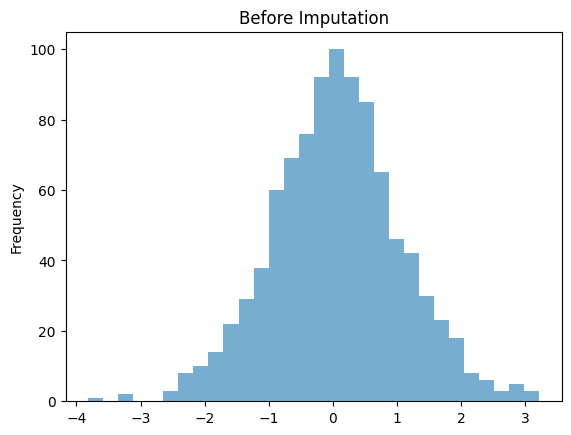

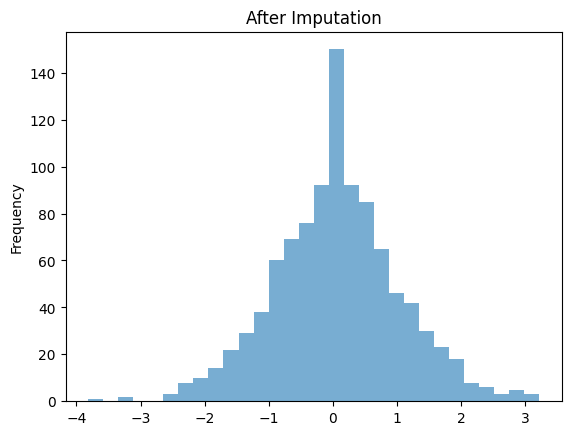

In [4]:
'''
Question 8: Write a Python script to:
● Generate 1000 samples from a normal distribution.
● Introduce 50 random missing values.
● Fill missing values with the column mean.
● Plot a histogram before and after imputation.
(Include your Python code and output in the code box below.)
'''

# Answer 8:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate 1000 samples from normal distribution
data = np.random.randn(1000)

# Introduce 50 random missing values
data[np.random.choice(1000, 50, replace=False)] = np.nan
df = pd.DataFrame(data, columns=["Value"])

# Plot before imputation
df["Value"].plot(kind="hist", bins=30, alpha=0.6, title="Before Imputation")
plt.show()

# Fill missing values with mean
df["Value"].fillna(df["Value"].mean(), inplace=True)

# Plot after imputation
df["Value"].plot(kind="hist", bins=30, alpha=0.6, title="After Imputation")
plt.show()


In [10]:
'''
Question 9: Implement Min-Max scaling on the following list of numbers [2, 5, 10, 15,
20] using sklearn.preprocessing.MinMaxScaler. Print the scaled array.
(Include your Python code and output in the code box below.)
'''

# Answer 9:

from sklearn.preprocessing import MinMaxScaler
import numpy as np

data = np.array([[2], [5], [10], [15], [20]])
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

print(scaled.flatten())


[0.         0.16666667 0.44444444 0.72222222 1.        ]


In [9]:
'''
Question 10: You are working as a data scientist for a retail company. You receive a customer
transaction dataset that contains:
● Missing ages,
● Outliers in transaction amount,
● A highly imbalanced target (fraud vs. non-fraud),
● Categorical variables like payment method.
Explain the step-by-step data preparation plan you’d follow before training a machine learning
model. Include how you’d address missing data, outliers, imbalance, and encoding.
(Include your Python code and output in the code box below.)
'''

# Answer 10:

#1. Missing Ages: Impute with mean/median for numerical data.

import pandas as pd
import numpy as np

df["Age"].fillna(df["Age"].median(), inplace=True)


#2. Outliers in Transaction Amount: Detect using IQR or Z-score, then cap or remove.


Q1, Q3 = df["Amount"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df["Amount"] = np.where(df["Amount"] > upper, upper,
                        np.where(df["Amount"] < lower, lower, df["Amount"]))


#3. Imbalanced Target (Fraud vs. Non-fraud): Use resampling techniques like SMOTE or class weights.

from imblearn.over_sampling import SMOTE
X_res, y_res = SMOTE().fit_resample(X, y)



#4. Categorical Variables (Payment Method): Encode using one-hot encoding.

df = pd.get_dummies(df, columns=["PaymentMethod"])



KeyError: 'Age'